# **Homework 3**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

### **Connecting Google Drive To Import Dataset**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Importing Required Libraries**

In [15]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


### **Loading dataset & Defining Student ID**

In [16]:
titanic = pd.read_csv('drive/MyDrive/Titanic.csv')
Student_Id = 20033031
# Display the first few rows of the dataframe
titanic.head()

,Unnamed: 0,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1st,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.337494,B5,Southampton,2,NaN,"St Louis, MO"
1,2,1st,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.550003,C22 C26,Southampton,11,NaN,"Montreal, PQ / Chesterville, ON"
2,3,1st,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,4,1st,0,"Allison, Mr. Hudson Joshua Crei",male,30.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,5,1st,0,"Allison, Mrs. Hudson J C (Bessi",female,25.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"


# Step 1

In [17]:
def QuantileBinning(feature, bin_number):
    """
    This function takes a numerical feature and the number of bins, and
    returns the feature binned into quantile-based bins.

    Parameters:
    - feature (pandas.Series): The numerical feature to be binned.
    - bin_number (int): The number of quantile bins.

    Returns:
    - pandas.Series: A series of discrete features binned by quantile.
    """
    # Use qcut to create quantile-based bins for the feature
    # If there are fewer unique values than bins, qcut could throw an error.
    # 'duplicates' parameter handles this by dropping redundant bins.
    return pd.qcut(feature, q=bin_number, labels=False, duplicates='drop')

# One example
feature_test = pd.DataFrame(np.random.rand(100),  columns=['Column_A'])
feature_test_discrete = QuantileBinning(feature_test['Column_A'], 10)

def label_encoder(feature):
    unique_labels = pd.unique(feature)
    label_to_int = {label: idx for idx, label in enumerate(unique_labels)}
    transformed_feature = np.array([label_to_int[label] for label in feature])
    return transformed_feature

In [26]:
print("\nMissing values in each column:")
print(titanic.isnull().sum())

# Fill missing values in 'age' with the average age
titanic['age'].fillna(titanic['age'].mean(), inplace=True)

# Select the subset of data including the required variables
data = titanic[['pclass', 'sex', 'age', 'sibsp', 'survived']]

# Convert pclass from categorical to numeric (1st to 0, 2nd to 1, 3rd to 2)
data['pclass'] = data['pclass'].map({'1st': 0, '2nd': 1, '3rd': 2})

# Conerting 'sex' as a binary variable (0 for male, 1 for female)
data['sex'] = data['sex'].map({'male': 0, 'female': 1})

# Check if 'survived' is a binary variable (should be 0 or 1)
data['survived'] = data['survived'].astype(int)

# Discretize 'age' using 8 quantile bins
data['age'] = QuantileBinning(data['age'], 8)

# Split the data into 80% training and 20% test sets
training, testing = train_test_split(data, test_size=0.2, random_state=Student_Id)

training.shape, testing.shape


Missing values in each column:
pclass      0
sex         0
age         0
sibsp       0
survived    0
dtype: int64


<ipython-input-26-ed7be65e27a9>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].mean(), inplace=True)


((1047, 5), (262, 5))

In [25]:
training.head()

,pclass,sex,age,sibsp,survived
668,2,1,1,0,0
233,0,0,6,0,1
1297,2,1,3,0,0
1046,2,1,1,0,0
10,0,1,6,1,0


# Step 2

In [28]:
# define your entropy function and information gain function
def entropy(y):
    """
    Parameters:
    y : Array of class labels.
    Returns:
    float: Entropy value.
    """
    if len(y) == 0:
        return 0
    p1 = len(y[y == 1]) / len(y) # Calculating probability of survival
    p0 = 1 - p1 # Calculating probability of non-survival
    # Handling edge cases
    if p1 == 0 or p0 == 0:
        return 0
    # Entropy formula: -p1*log2(p1) - p0*log2(p0)
    entropy_value = -p1 * np.log2(p1) - p0 * np.log2(p0)
    return entropy_value
# Calculate Information Gain for each feature in the training set

def information_gain(X, y, feature):
    """
    Parameters:
    X (DataFrame): Feature data.
    y (Series): Target labels.
    feature (str): The feature to calculate information gain for.
    Returns:
    float: Gain value.
    """
    parent_entropy = entropy(y) # Calculating entropy before splitting
    values = X[feature].unique()
    weighted_entropy = 0 # Calculating weighted entropy after splitting
    total_samples = len(y)

    for value in values:
        value_indices = X[feature] == value # Get indices of samples values
        value_targets = y[value_indices] # Get corresponding target values
        weight = len(value_targets) / total_samples # Calculating weight
        value_entropy = entropy(value_targets) # Calculating entropy for subset
        weighted_entropy += weight * value_entropy # Adding weighted entropy

    # Information gain = parent entropy - weighted entropy after split
    info_gain = parent_entropy - weighted_entropy
    return info_gain

In [32]:
# Calculating Information Gain for training set
features = ['pclass', 'sex', 'age', 'sibsp']
X_train = training[features]
y_train = training['survived']
X_test = testing[features]
y_test = testing['survived']
info_gains = {}
for feature in features:
    info_gains[feature] = information_gain(X_train, y_train, feature)

In [33]:
info_gains

{'pclass': 0.05969616445558379,
 'sex': 0.2008760660568787,
 'age': 0.013514860725802436,
 'sibsp': 0.027284919640928496}

In [35]:
best_feature = max(info_gains, key=info_gains.get)
best_feature

'sex'

So the first split should be "sex"

# Step 3

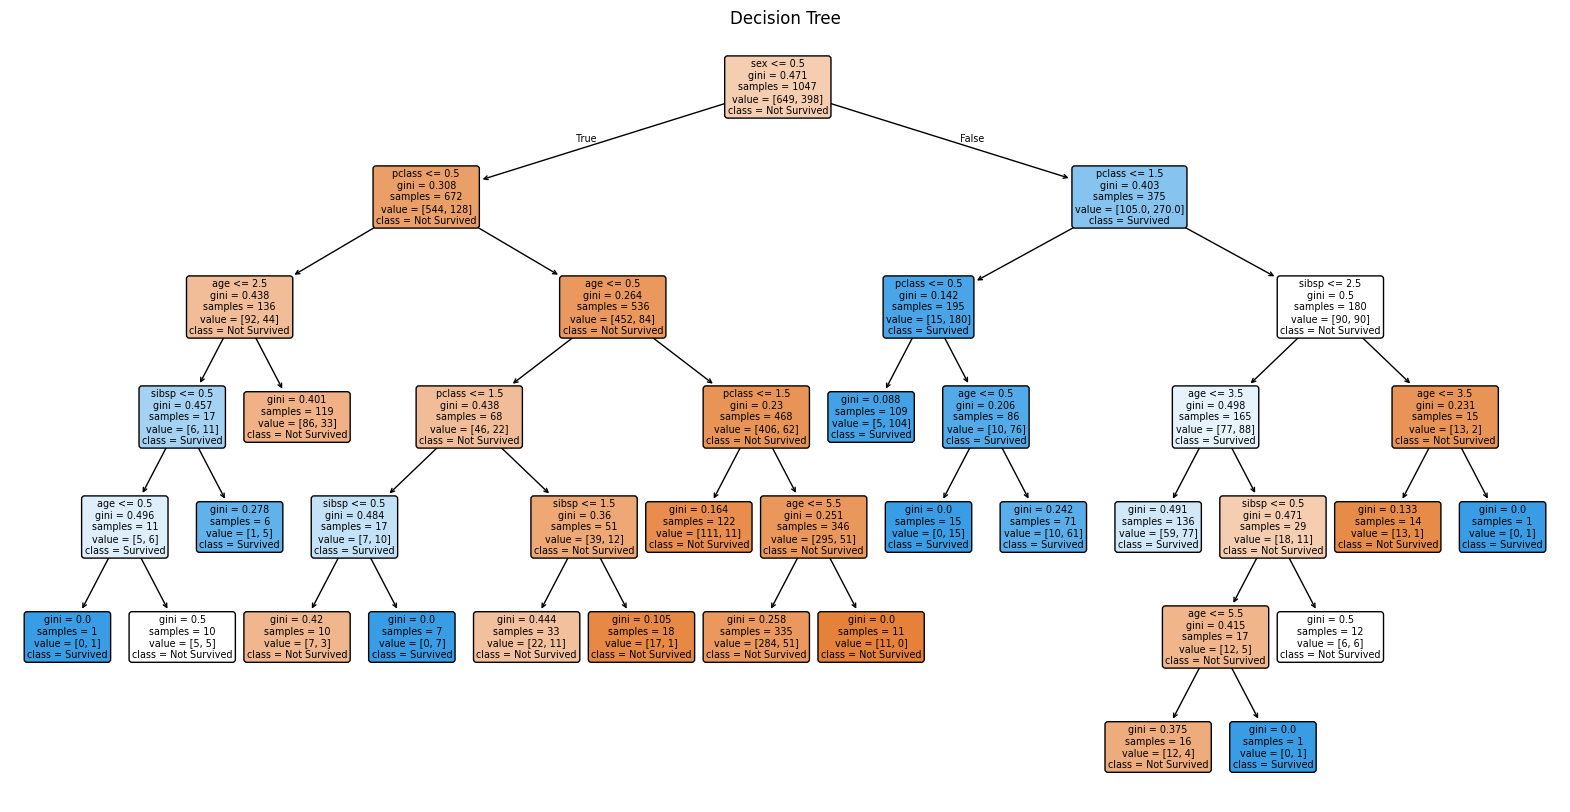

In [36]:
from sklearn.tree import DecisionTreeClassifier, plot_tree #sklearn.metrics is not imported !!!

# Instantiate the DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(max_leaf_nodes=20, random_state=Student_Id)

# Fit the decision tree model
dt_classifier.fit(X_train, y_train)

# Plot the full decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, filled=True, feature_names=features, class_names=['Not Survived', 'Survived'], rounded=True)
plt.title('Decision Tree')
plt.show()

In [54]:
# Define your performance metrics including accuracy, precision, recall and F1-scorre
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)

# Calculate performance metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
performance_metrics = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    }
performance_metrics

{'Accuracy': 0.8091603053435115,
 'Precision': 0.7954545454545454,
 'Recall': 0.6862745098039216,
 'F1 Score': 0.7368421052631579}

# Step 4

Optimal max_leaf_nodes:  15
Best cross-validation score: 0.7956892230576441


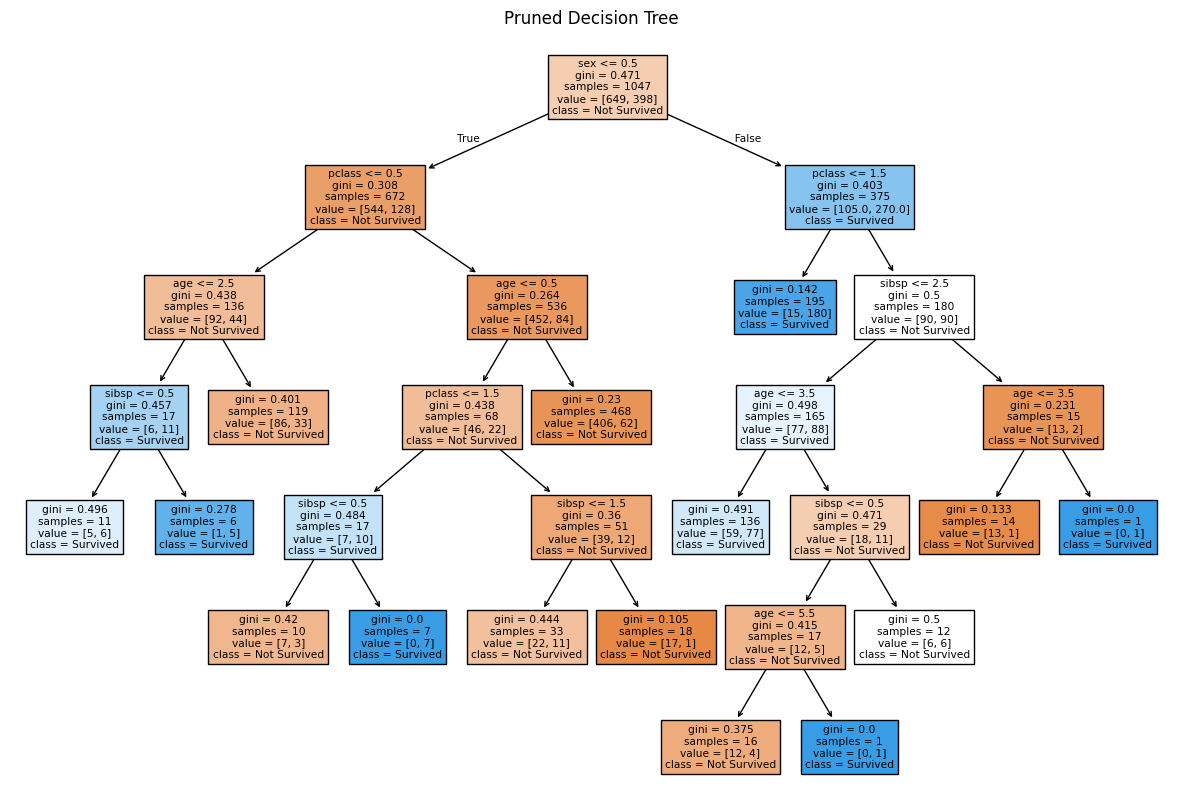

In [41]:
from sklearn.model_selection import GridSearchCV

# Define a range of max_leaf_nodes values to search
param_grid = {'max_leaf_nodes': list(range(5, 20))}

# Run grid search with cross-validation
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train) # Note testing set cannot be used

# Get the best estimator with the optimal max_leaf_nodes parameter
best_tree = grid_search.best_estimator_
best_max_leaf_nodes = grid_search.best_params_['max_leaf_nodes']
print("Optimal max_leaf_nodes: ", best_max_leaf_nodes)
print("Best cross-validation score:", grid_search.best_score_)

# Plot the pruned decision tree
plt.figure(figsize=(15, 10))
plot_tree(best_tree, filled=True, feature_names=features, class_names=['Not Survived', 'Survived'])
plt.title('Pruned Decision Tree')
plt.show()

In [53]:
y_pred_pruned = best_tree.predict(X_test)

acc = accuracy_score(y_test, y_pred_pruned)
prec = precision_score(y_test, y_pred_pruned)
rec = recall_score(y_test, y_pred_pruned)
f1 = f1_score(y_test, y_pred_pruned)
pruned_performance = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    }
pruned_performance

{'Accuracy': 0.8015267175572519,
 'Precision': 0.7777777777777778,
 'Recall': 0.6862745098039216,
 'F1 Score': 0.7291666666666666}

# Step 5


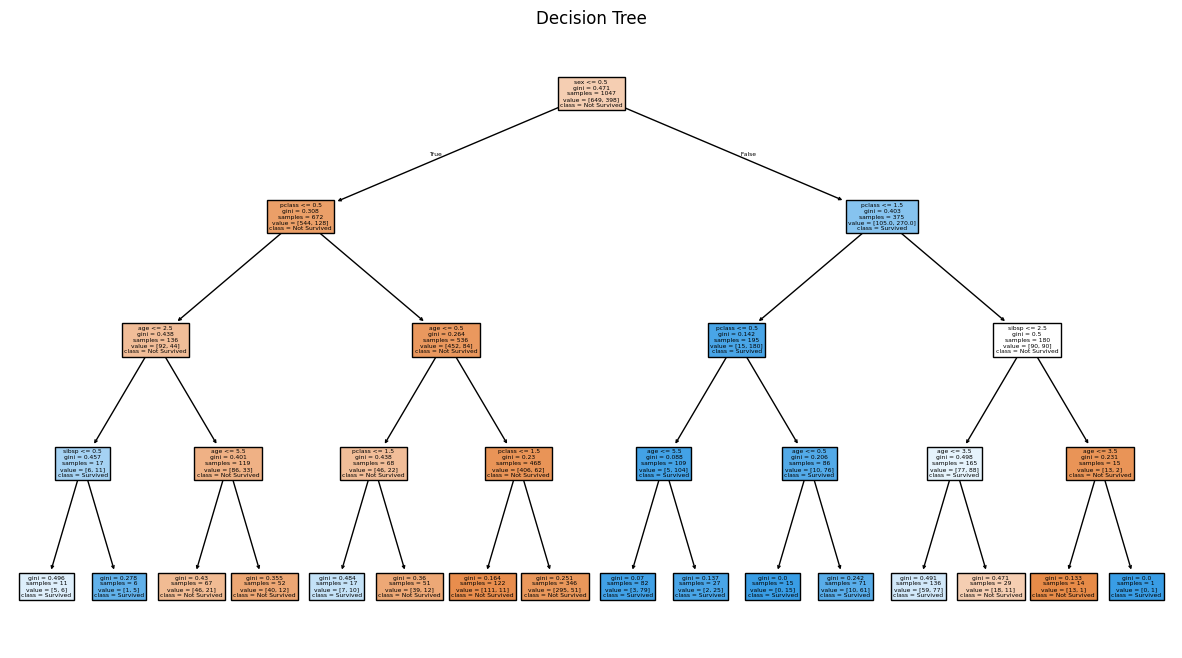

In [50]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Tree with max_depth
dt_max_depth = DecisionTreeClassifier(max_depth=4, random_state=Student_Id)
dt_max_depth.fit(X_train, y_train)

# Tree with criterion
dt_opt_criteria = DecisionTreeClassifier(criterion='gini', max_leaf_nodes=best_max_leaf_nodes, random_state=Student_Id)
dt_opt_criteria.fit(X_train, y_train)

# max_depth tree
plt.figure(figsize=(15, 8))
plot_tree(dt_max_depth, filled=True, feature_names=features, class_names=['Not Survived', 'Survived'])
plt.title('Decision Tree')
plt.show()